In [14]:
import numpy as np
import pandas as pd
import sys
import importlib
import matplotlib.pyplot as plt

sys.path.append('../src')
import policies 
import bbDebiasing
import maxEnsembleDebias

sys.path.append('folktables-pipeline')
import acsData

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import zero_one_loss, mean_squared_error

#test

In [73]:
importlib.reload(acsData)
acs_year = '2016'

class State:
    def __init__(self, name):
        self.name = name
        self.features, self.targets = acsData.get_data(acs_year, [self.name])
        
        target_transform=lambda x: x > 50000
        self.bool_targets = target_transform(self.targets)

        self.features_train, self.features_test, self.target_train, self.target_test = train_test_split(
        self.features, self.bool_targets, test_size=0.3, random_state=42)

        self.model = make_pipeline(StandardScaler(), LogisticRegression())
    
    def trainStateModel(self):
        self.model.fit(self.features_train, self.target_train)  
        
stateNames = ['CA', 'OR', 'AK']
stateList = []   
allData = None

for stateName in stateNames:
    newState = State(stateName)
    newState.trainStateModel()
    stateList.append(newState)

Text(0.5, 1.0, 'Normalized Income Distribution by State (Under 100k)')

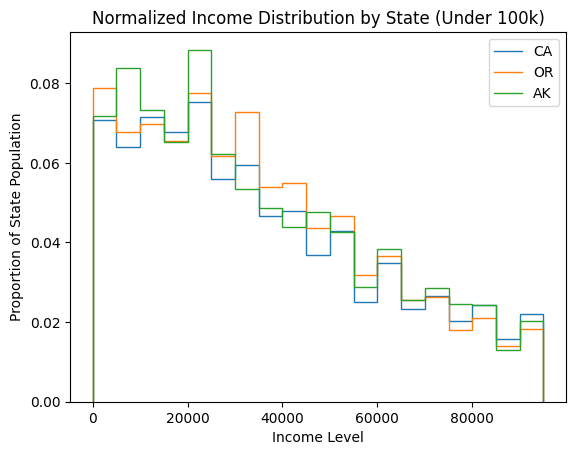

In [80]:
for state in stateList:
    counts, bins = np.histogram(state.targets, bins=np.arange(0,100000,5000))
    plt.stairs(counts/len(state.targets), bins, label=state.name)
plt.legend()
plt.xlabel('Income Level')
plt.ylabel('Proportion of State Population')
plt.title('Normalized Income Distribution by State (Under 100k)')

In [75]:
mses = np.zeros((len(stateList), len(stateList)))

for i,state1 in enumerate(stateList):
    for j,state2 in enumerate(stateList):
        # state 1 model's performance on state 2 test data
        mses[i][j] = mean_squared_error(state2.target_test, state1.model.predict_proba(state2.features_test)[:,1])

In [77]:
df = pd.DataFrame(mses, stateNames, stateNames)
df.style.apply(lambda col: ['font-weight:bold' if x==col.min() else '' for x in col], axis=1)

,CA,OR,AK
CA,0.145102,0.152602,0.154560
OR,0.153803,0.146826,0.158409
AK,0.156537,0.157822,0.151193


In [82]:
features, targets = acsData.get_data(acs_year, stateNames)
target_transform=lambda x: x > 50000
boolTargets = target_transform(targets)
x_train, x_test, y_train, y_test = train_test_split(features, boolTargets)

In [ ]:
models = [state.model for state in stateList]
init_model = models[0]

policy = policies.Simplex(2, models[0])

bbModel = bbDebiasing.bbDebias(init_model, policy)

